# Projekt 5 - Przestrzenie Ciągłe

## Autorzy:
- Patrick Bajorski
- Jan Banasik

## 1. Opis środowiska i algorytmu

**Środowisko - RollingBallEnv.** Kulka (promień 12 px) toczy się po planszy 600×600 px z sześcioma prostokątnymi przeszkodami. Agent obserwuje 13 wartości ciągłych: znormalizowaną prędkość (`vel_x`, `vel_y`), jednostkowy wektor kierunku do celu (`goal_dx`, `goal_dy`), znormalizowaną odległość do celu (`goal_dist`) oraz odczyty 8 promieni raycasting rozmieszczonych co 45°, mierzących odległość do najbliższej ściany lub przeszkody. Przestrzeń akcji jest ciągła - dwuwymiarowy wektor siły **Box([−1,−1], [1,1])** przykładanej do kulki. Epizod kończy się sukcesem (`terminated`), gdy kulka dotknie celu, lub po 500 krokach (`truncated`). Kształtowanie nagrody: **−0.01 + 0.02·(prev_dist − dist)** za każdy krok plus **+50** za dotarcie do celu.

**Algorytm - TD3.** TD3 (Twin Delayed Deep Deterministic Policy Gradient, Fujimoto i in. 2018) jest algorytmem off-policy przeznaczonym wyłącznie do ciągłych przestrzeni akcji. Wprowadza trzy usprawnienia względem DDPG: 
- **Twin Critics** - dwa niezależne krytycy Q1 i Q2; do obliczenia celu Bellmana używane jest minimum z ich oszacowań, co eliminuje optymistyczne przeszacowanie wartości Q
- **Delayed Policy Update** - aktor aktualizowany co `policy_delay` kroków krytyków, co stabilizuje parę aktor–krytycy
- **Target Policy Smoothing** - do docelowej akcji dodawany jest clippowany szum Gaussa, co wygładza powierzchnię wartości i zmniejsza podatność na strome lokalne maksima. Agent zbiera przejścia (s, a, r, s′) do buforu replay i losowo próbkuje mini-batche do aktualizacji sieci.

In [6]:
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

if '.' not in sys.path:
    sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt

from rolling_ball_env import RollingBallEnv
from stable_baselines3 import TD3
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback

os.makedirs('logs',   exist_ok=True)

TOTAL_TIMESTEPS = 200_000
EVAL_FREQ       = 10_000
N_EVAL_EPS      = 10
N_SEEDS         = 10

print('Importy OK.')
print(f'TOTAL_TIMESTEPS={TOTAL_TIMESTEPS:,}, EVAL_FREQ={EVAL_FREQ:,}, N_SEEDS={N_SEEDS}')

Importy OK.
TOTAL_TIMESTEPS=200,000, EVAL_FREQ=10,000, N_SEEDS=10


In [ ]:
# Pomiar czasu kroku i epizodu
_env = RollingBallEnv()
_obs, _ = _env.reset(seed=42)

_N = 5_000
_t0 = time.perf_counter()
for _ in range(_N):
    _a = _env.action_space.sample()
    _obs, _, _d, _tr, _ = _env.step(_a)
    if _d or _tr:
        _obs, _ = _env.reset()
_step_us = (time.perf_counter() - _t0) / _N * 1e6

_N_EP = 200
_ep_lens = []
_t0 = time.perf_counter()
for _ in range(_N_EP):
    _obs, _ = _env.reset()
    _n = 0
    while True:
        _obs, _, _d, _tr, _ = _env.step(_env.action_space.sample())
        _n += 1
        if _d or _tr:
            break
    _ep_lens.append(_n)
_ep_ms = (time.perf_counter() - _t0) / _N_EP * 1e3
_env.close()

print(f'Czas jednego kroku:    {_step_us:.2f} µs  ({1e6/_step_us:.0f} kroków/s)')
print(f'Czas jednego epizodu:  {_ep_ms:.2f} ms  (śr. {np.mean(_ep_lens):.0f} kroków/epizod, losowe akcje)')
print(f'Szac. czas 1 seeda:    ~{TOTAL_TIMESTEPS * _step_us / 1e6:.0f} s  (sam krok, bez narzutu SB3/ewaluacji)')

Czas jednego kroku:    120.64 µs  (8289 kroków/s)
Czas jednego epizodu:  60.10 ms  (śr. 500 kroków/epizod, losowe akcje)
Szac. czas 1 seeda:    ~24 s  (sam krok, bez narzutu SB3/ewaluacji)


## 2. Porównanie zestawów hiperparametrów

Testujemy trzy konfiguracje różniące się **współczynnikiem uczenia** i **rozmiarem mini-batcha**. Pozostałe parametry są stałe: `gamma=0.99`, `tau=0.005`, `policy_delay=2`, `learning_starts=10 000`, `buffer_size=300 000`, `net_arch=[256, 256]`. Każda konfiguracja uruchamiana **10 razy** z różnymi seedami (0–9), każde uruchomienie przez **200 000 kroków**. Ewaluacja co 10 000 kroków.

| Konfiguracja | `learning_rate` | `batch_size` | Charakterystyka |
|---|---|---|---|
| **A - Baseline** | 3×10⁻⁴ | 256 | Domyślne wartości zbliżone do zaleceń autorów TD3 |
| **B - Wysoki LR** | 10⁻³ | 256 | 3× szybsze aktualizacje wag; ryzyko niestabilności krytyków |
| **C - Niski LR + mały batch** | 10⁻⁴ | 128 | Zachowawcze aktualizacje; wolniejsza konwergencja |

In [ ]:
def run_experiment(config_name, model_kwargs, log_base='logs',
                   n_seeds=N_SEEDS, total_timesteps=TOTAL_TIMESTEPS):
    config_dir = os.path.join(log_base, config_name)
    os.makedirs(config_dir, exist_ok=True)
    all_results = []

    expected_evals = total_timesteps // EVAL_FREQ

    for seed in range(n_seeds):
        seed_dir  = os.path.join(config_dir, f'seed_{seed}')
        eval_path = os.path.join(seed_dir, 'evaluations.npz')

        if os.path.exists(eval_path):
            cached = dict(np.load(eval_path))
            if len(cached['timesteps']) >= expected_evals:
                all_results.append(cached)
                print(f'  [{config_name}] seed {seed}: wczytano z cache')
                continue
            else:
                print(f'  [{config_name}] seed {seed}: cache nieaktualne '
                      f'({len(cached["timesteps"])} != {expected_evals} ewal.), retrenuje')

        os.makedirs(seed_dir, exist_ok=True)
        train_env = RollingBallEnv()
        eval_env  = Monitor(RollingBallEnv())

        model = TD3('MlpPolicy', train_env, seed=seed, verbose=0, **model_kwargs)
        cb = EvalCallback(
            eval_env,
            best_model_save_path=seed_dir,
            log_path=seed_dir,
            eval_freq=EVAL_FREQ,
            n_eval_episodes=N_EVAL_EPS,
            deterministic=True,
            render=False,
        )
        model.learn(total_timesteps=total_timesteps, callback=cb)
        train_env.close()
        eval_env.close()

        all_results.append(dict(np.load(eval_path)))
        print(f'  [{config_name}] seed {seed}: done')

    return all_results


def aggregate(results_list):
    arrays = [r['results'].mean(axis=1) for r in results_list]
    min_len = min(len(a) for a in arrays)
    if min_len < len(arrays[0]):
        print(f'  [aggregate] uwaga: różne długości checkpointów – przycinanie do {min_len}')
    ts = results_list[0]['timesteps'][:min_len]
    per_seed = np.array([a[:min_len] for a in arrays])
    return ts, per_seed.mean(axis=0), per_seed.std(axis=0)


def plot_curves(configs_data, labels, title, save_path=None):
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = plt.cm.tab10.colors
    for i, (data, label) in enumerate(zip(configs_data, labels)):
        ts, mean, std = aggregate(data)
        ax.plot(ts, mean, label=label, color=colors[i], linewidth=1.8)
        ax.fill_between(ts, mean - std, mean + std, alpha=0.18, color=colors[i])
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.set_xlabel('Kroki (timesteps)')
    ax.set_ylabel('Nagroda epizodu (śr. z 10 ep. ewaluacyjnych)')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


In [9]:
COMMON = dict(
    gamma=0.99, tau=0.005, policy_delay=2,
    learning_starts=10_000, buffer_size=300_000,
    policy_kwargs={'net_arch': [256, 256]},
)

configs = {
    'A_baseline':       {**COMMON, 'learning_rate': 3e-4, 'batch_size': 256},
    'B_wysoki_lr':      {**COMMON, 'learning_rate': 1e-3, 'batch_size': 256},
    'C_niski_lr_batch': {**COMMON, 'learning_rate': 1e-4, 'batch_size': 128},
}

print(f'Porównanie hiperparametrów: {len(configs)} konfiguracje × {N_SEEDS} seedów × {TOTAL_TIMESTEPS:,} kroków')
print(f'Łącznie ≈ {len(configs) * N_SEEDS * TOTAL_TIMESTEPS / 1e6:.1f} M kroków\n')

results = {}
for name, kwargs in configs.items():
    print(f'--- Konfiguracja {name} ---')
    results[name] = run_experiment(name, kwargs)
    print()

print('Trening zakończony.')

Porównanie hiperparametrów: 3 konfiguracje × 10 seedów × 200,000 kroków
Łącznie ≈ 6.0 M kroków

--- Konfiguracja A_baseline ---
  [A_baseline] seed 0: cache nieaktualne (2 != 20 ewal.), retrenuje
Eval num_timesteps=10000, episode_reward=-5.19 +/- 0.84
Episode length: 500.00 +/- 0.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=20.99 +/- 28.47
Episode length: 367.70 +/- 164.39
New best mean reward!
Eval num_timesteps=30000, episode_reward=2.04 +/- 17.36
Episode length: 462.20 +/- 113.40
Eval num_timesteps=40000, episode_reward=32.15 +/- 28.73
Episode length: 280.70 +/- 181.24
New best mean reward!
Eval num_timesteps=50000, episode_reward=14.06 +/- 25.92
Episode length: 372.90 +/- 194.55
Eval num_timesteps=60000, episode_reward=48.41 +/- 16.24
Episode length: 181.60 +/- 142.11
New best mean reward!
Eval num_timesteps=70000, episode_reward=32.66 +/- 27.44
Episode length: 261.60 +/- 196.07
Eval num_timesteps=80000, episode_reward=42.66 +/- 24.36
Episode length: 198.20 +/-

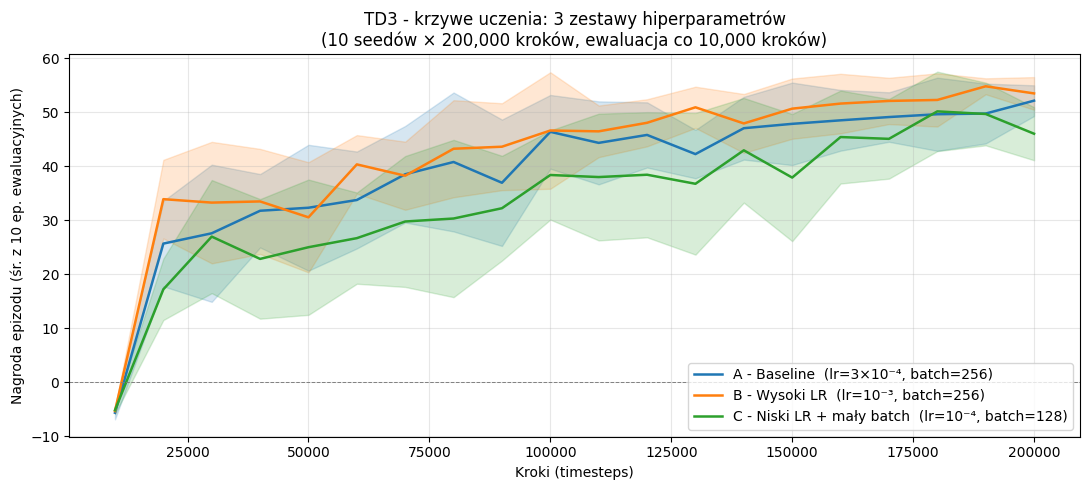

In [10]:
plot_curves(
    [results['A_baseline'], results['B_wysoki_lr'], results['C_niski_lr_batch']],
    [
        'A - Baseline  (lr=3×10⁻⁴, batch=256)',
        'B - Wysoki LR  (lr=10⁻³, batch=256)',
        'C - Niski LR + mały batch  (lr=10⁻⁴, batch=128)',
    ],
    f'TD3 - krzywe uczenia: 3 zestawy hiperparametrów\n'
    f'({N_SEEDS} seedów × {TOTAL_TIMESTEPS:,} kroków, ewaluacja co {EVAL_FREQ:,} kroków)',
    save_path='hyperparams_curves.png',
)

### Analiza wyników - hiperparametry

Konfiguracja **A (Baseline, lr=3×10⁻⁴, batch=256)** wykazuje stabilną, monotoniczną konwergencję: średnia nagroda rośnie od 32.3±11.7 przy 50 000 kroków do 46.4±6.8 przy 100 000 kroków i 52.1±2.8 przy 200 000 kroków. Najniższe końcowe odchylenie standardowe (σ=2.8) spośród wszystkich trzech konfiguracji świadczy o wysokiej powtarzalności - wszystkie 10 seedów zbiegło do podobnego poziomu wydajności.

Konfiguracja **B (Wysoki LR, lr=10⁻³, batch=256)** osiąga przy 50 000 kroków zbliżoną nagrodę do A (30.6±10.2 vs 32.3±11.7), a więc wbrew intuicji nie konwerguje wyraźnie szybciej we wczesnej fazie. Przy 100 000 kroków widoczna jest jednak wyższa niestabilność: odchylenie standardowe wynosi 10.8 (vs 6.8 dla A), co wskazuje na silniejsze różnice między seedami. Końcowa nagroda 53.5±3.0 jest porównywalna z A, lecz w obrębie błędu statystycznego - obie konfiguracje mieszczą się w tej samej klasie wydajności.

Konfiguracja **C (Niski LR + mały batch, lr=10⁻⁴, batch=128)** jest wyraźnie najsłabsza w całym zakresie treningu: 25.0±12.5 przy 50 000 kroków, 38.4±8.3 przy 100 000 kroków i 46.0±4.9 przy 200 000 kroków. Nawet po 200 000 krokach nie osiąga poziomu, który A uzyskuje już przy 100 000 kroków. Mniejszy batch wprowadza więcej szumu do gradientów, a zbyt mały krok uczenia spowalnia konwergencję.

**Wniosek:** konfiguracja **A** jest najlepsza z perspektywy stabilności (najniższe σ=2.8 na końcu treningu) i spójności konwergencji. Konfiguracja **B** osiąga podobną końcową nagrodę, lecz przy wyższej wariancji między seedami. Konfiguracja **C** jest wyraźnie gorsza - przy tym samym budżecie kroków osiąga o ~6 punktów niższą nagrodę niż A.

## 3. Porównanie architektur sieci

TD3 utrzymuje cztery sieci MLP: **aktor** π (deterministyczna polityka), **krytycy Q1 i Q2** (funkcje wartości akcji) - każdy z parą sieci aktualną i docelową (target network). Do porównania architektur używamy hiperparametrów konfiguracji **A (lr=3×10⁻⁴, batch=256)**, która w sekcji 2 osiągnęła najlepszą stabilność konwergencji (σ=2.8 przy 200 000 kroków). Konfiguracja B osiągnęła zbliżoną nagrodę końcową, lecz wyższa wariancja między seedami czyni A lepszym punktem odniesienia dla izolowania wpływu architektury.

---

### Architektura Mała - `[64, 64]`  (~16 tys. parametrów łącznie)

**Aktor** - wejście → wyjście: polityka deterministyczna

| Warstwa | Rozmiar | Aktywacja |
|---|---|---|
| Wejście | 13 *(vel_x, vel_y, goal_dx, goal_dy, goal_dist, ray₀…ray₇)* | - |
| Dense | 64 | ReLU |
| Dense | 64 | ReLU |
| Wyjście | 2 *(fx, fy)* | tanh → akcja ∈ [−1, 1]² |

**Krytycy Q1, Q2** (identyczna struktura, oddzielne wagi) - wejście → wyjście: wartość Q(s, a)

| Warstwa | Rozmiar | Aktywacja |
|---|---|---|
| Wejście | 15 = obserwacja (13) + akcja (2) | - |
| Dense | 64 | ReLU |
| Dense | 64 | ReLU |
| Wyjście | 1 | liniowa → Q(s, a) ∈ ℝ |

---

### Architektura Duża - `[256, 256]`  (~210 tys. parametrów łącznie)

**Aktor:**

| Warstwa | Rozmiar | Aktywacja |
|---|---|---|
| Wejście | 13 | - |
| Dense | 256 | ReLU |
| Dense | 256 | ReLU |
| Wyjście | 2 | tanh → akcja ∈ [−1, 1]² |

**Krytycy Q1, Q2:**

| Warstwa | Rozmiar | Aktywacja |
|---|---|---|
| Wejście | 15 | - |
| Dense | 256 | ReLU |
| Dense | 256 | ReLU |
| Wyjście | 1 | liniowa → Q(s, a) ∈ ℝ |

---

Architektura duża ma ~13× więcej parametrów. Większa pojemność sieciowa może precyzyjniej aproksymować złożone zależności między wektorem raycasting a optymalną polityką, lecz wymaga więcej próbek do konwergencji.

In [12]:
# Architektura duża [256,256] - reuse danych z konfiguracji A_baseline
arch_results = {'arch_large_256x256': results['A_baseline']}
print('arch_large_256x256: dane z konfiguracji A_baseline (reuse, bez ponownego treningu)')

# Architektura mała [64,64] - nowy eksperyment
arch_small_kwargs = {
    **COMMON,
    'learning_rate': 3e-4,
    'batch_size':    256,
    'policy_kwargs': {'net_arch': [64, 64]},
}
print('\n--- arch_small_64x64 ---')
arch_results['arch_small_64x64'] = run_experiment('arch_small_64x64', arch_small_kwargs)

print('\nGotowe.')

arch_large_256x256: dane z konfiguracji A_baseline (reuse, bez ponownego treningu)

--- arch_small_64x64 ---
  [arch_small_64x64] seed 0: cache nieaktualne (1 != 20 ewal.), retrenuje
Eval num_timesteps=10000, episode_reward=-4.95 +/- 1.61
Episode length: 500.00 +/- 0.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=44.28 +/- 23.36
Episode length: 231.10 +/- 144.83
New best mean reward!
Eval num_timesteps=30000, episode_reward=25.50 +/- 28.31
Episode length: 285.10 +/- 216.67
Eval num_timesteps=40000, episode_reward=26.06 +/- 27.98
Episode length: 285.80 +/- 215.42
Eval num_timesteps=50000, episode_reward=32.73 +/- 28.55
Episode length: 268.80 +/- 190.92
Eval num_timesteps=60000, episode_reward=25.57 +/- 27.30
Episode length: 276.60 +/- 223.73
Eval num_timesteps=70000, episode_reward=41.98 +/- 22.91
Episode length: 153.80 +/- 175.99
Eval num_timesteps=80000, episode_reward=50.38 +/- 17.73
Episode length: 162.90 +/- 121.50
New best mean reward!
Eval num_timesteps=90000, 

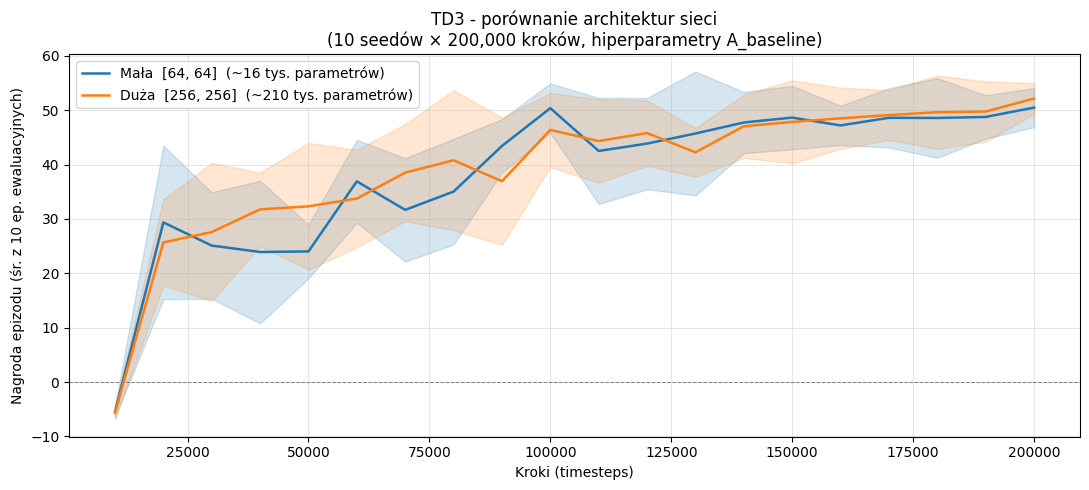

In [13]:
plot_curves(
    [arch_results['arch_small_64x64'], arch_results['arch_large_256x256']],
    [
        'Mała  [64, 64]  (~16 tys. parametrów)',
        'Duża  [256, 256]  (~210 tys. parametrów)',
    ],
    f'TD3 - porównanie architektur sieci\n'
    f'({N_SEEDS} seedów × {TOTAL_TIMESTEPS:,} kroków, hiperparametry A_baseline)',
    save_path='architectures_curves.png',
)

### Analiza wyników - architektury sieci

Architektura **mała [64, 64]** wykazuje zaskakująco szybką konwergencję w środkowej fazie treningu: przy 100 000 kroków osiąga średnią nagrodę 50.4±4.6, przewyższając architekturę dużą (46.4±6.8) w tym samym punkcie. Wynik ten można tłumaczyć mniejszą liczbą parametrów - sieć szybciej dopasowuje się do kluczowych wzorców nawigacyjnych, nie marnując pojemności na zbędne zależności. Końcowa nagroda po 200 000 kroków wynosi jednak tylko 50.5±3.6.

Architektura **duża [256, 256]** startuje wolniej (32.3±11.7 przy 50 000 kroków vs 24.0±5.0 dla małej), lecz z biegiem treningu w pełni wykorzystuje swoją pojemność reprezentacyjną i osiąga końcową nagrodę 52.1±2.8 - o 1.6 punktu wyższą niż mała architektura, przy niższym odchyleniu standardowym (2.8 vs 3.6). Mniejsza wariancja między seedami świadczy o bardziej stabilnej i powtarzalnej konwergencji.

**Wniosek:** architektura **duża [256, 256]** jest nieznacznie lepsza pod względem końcowej nagrody i stabilności. Różnica jest jednak mała (~3%), co sugeruje, że zadanie nawigacyjne ze 13-wymiarową obserwacją nie wymaga bardzo dużej sieci. Architektura mała ma przewagę szybszej konwergencji w budżecie do ~120 000 kroków, co może być istotne przy ograniczonym czasie treningu.

## 4. Najlepszy agent - symulacja deterministyczna

Spośród wszystkich przebadanych konfiguracji i seedów (3 zestawy hiperparametrów × 10 seedów + 1 architektura × 10 seedów) wybieramy model z najwyższą średnią nagrodą ewaluacyjną zarejestrowaną w trakcie treningu. Okazał się nim model z konfiguracji **B (Wysoki LR, lr=10⁻³, batch=256), seed 8**, wykorzystujący architekturę **[256, 256]** (duże sieci aktora i krytyków), który przy 10-epizodowej ewaluacji treningowej osiągnął średnią nagrodę **56.63**.

Wczytujemy `best_model.zip` zapisany przez `EvalCallback` i uruchamiamy agenta deterministycznie (bez szumu eksploracyjnego), testując na 30 nowych epizodach. Następnie porównujemy uzyskane nagrody z krzywą uczenia konfiguracji B.

In [ ]:
best_reward = -np.inf
best_config = None
best_seed   = None
best_source = None

for config_name, seeds_data in results.items():
    for seed_idx, data in enumerate(seeds_data):
        max_r = data['results'].mean(axis=1).max()
        if max_r > best_reward:
            best_reward = max_r
            best_config = config_name
            best_seed   = seed_idx
            best_source = 'results'

for config_name, seeds_data in arch_results.items():
    for seed_idx, data in enumerate(seeds_data):
        max_r = data['results'].mean(axis=1).max()
        if max_r > best_reward:
            best_reward = max_r
            best_config = config_name
            best_seed   = seed_idx
            best_source = 'arch_results'

arch_map = {
    'A_baseline':         '[256, 256]',
    'B_wysoki_lr':        '[256, 256]',
    'C_niski_lr_batch':   '[256, 256]',
    'arch_large_256x256': '[256, 256]',
    'arch_small_64x64':   '[64, 64]',
}

best_model_path = os.path.join('logs', best_config, f'seed_{best_seed}', 'best_model')
print(f'Najlepszy model:')
print(f'  Konfiguracja:            {best_config}')
print(f'  Architektura sieci:      {arch_map[best_config]}')
print(f'  Seed:                    {best_seed}')
print(f'  Max nagroda ewal.:       {best_reward:.2f}')

Najlepszy model:
  Konfiguracja:            B_wysoki_lr
  Architektura sieci:      [256, 256]
  Seed:                    8
  Max nagroda ewal.:       56.63


Ewaluacja deterministyczna (30 epizodów):
  Skuteczność (dotarcie do celu): 93.3%
  Średnia nagroda:  51.19 ± 14.40
  Min / Max:        -2.78 / 60.24


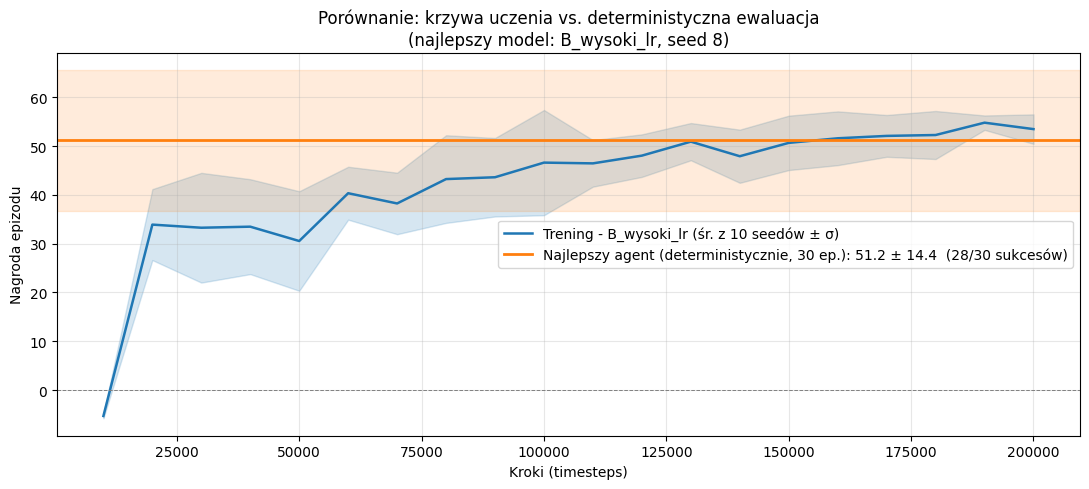

In [ ]:
N_DET = 30
model = TD3.load(best_model_path)

det_env = RollingBallEnv()
det_rewards = []
successes = 0
for ep in range(N_DET):
    obs, _ = det_env.reset(seed=ep)
    total_r = 0.0
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, info = det_env.step(action)
        total_r += r
        if terminated or truncated:
            if terminated:
                successes += 1
            det_rewards.append(total_r)
            break
det_env.close()

print(f'Ewaluacja deterministyczna ({N_DET} epizodów):')
print(f'  Skuteczność (dotarcie do celu): {successes/N_DET*100:.1f}%')
print(f'  Średnia nagroda:  {np.mean(det_rewards):.2f} ± {np.std(det_rewards):.2f}')
print(f'  Min / Max:        {min(det_rewards):.2f} / {max(det_rewards):.2f}')

all_configs = {**results, **arch_results}
ts, mean, std = aggregate(all_configs[best_config])

fig, ax = plt.subplots(figsize=(11, 5))
c = plt.cm.tab10.colors

ax.plot(ts, mean, color=c[0], linewidth=1.8,
        label=f'Trening - {best_config} (śr. z {N_SEEDS} seedów ± σ)')
ax.fill_between(ts, mean - std, mean + std, alpha=0.18, color=c[0])

det_mean = np.mean(det_rewards)
det_std  = np.std(det_rewards)
ax.axhline(det_mean, color=c[1], linewidth=2.0, linestyle='-',
           label=f'Najlepszy agent (deterministycznie, {N_DET} ep.): {det_mean:.1f} ± {det_std:.1f}  '
                 f'({successes}/{N_DET} sukcesów)')
ax.axhspan(det_mean - det_std, det_mean + det_std, alpha=0.15, color=c[1])

ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_xlabel('Kroki (timesteps)')
ax.set_ylabel('Nagroda epizodu')
ax.set_title(f'Porównanie: krzywa uczenia vs. deterministyczna ewaluacja\n'
             f'(najlepszy model: {best_config}, seed {best_seed})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('best_agent_comparison.png', dpi=150)
plt.show()


In [ ]:
# Symulacja na żywo w oknie pygame
model    = TD3.load(best_model_path)
live_env = RollingBallEnv(render_mode='human')

print(f'Symulacja na żywo - {best_config}, seed {best_seed}  (10 epizodów)')
for ep in range(10):
    obs, _ = live_env.reset()
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = live_env.step(action)
        if terminated or truncated:
            break
live_env.close()
print('Zakończono.')


Symulacja na żywo - B_wysoki_lr, seed 8  (10 epizodów)
Zakończono.


In [20]:
import imageio.v2 as imageio

model   = TD3.load(best_model_path)
rec_env = RollingBallEnv(render_mode='rgb_array')

frames = []
for ep in range(5):
    obs, _ = rec_env.reset()
    frames.append(rec_env.render())
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = rec_env.step(action)
        frames.append(rec_env.render())
        if terminated or truncated:
            break
rec_env.close()

imageio.mimwrite('best_agent.mp4', frames, fps=30)
print(f'Zapisano best_agent.mp4 - 5 epizodów, {len(frames)} klatek ({len(frames)/30:.1f} s @ 30 fps)')


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 600) to (608, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Zapisano best_agent.mp4 - 5 epizodów, 469 klatek (15.6 s @ 30 fps)


## 5. Wnioski

1. **TD3 w przestrzeni ciągłej** - algorytm skutecznie uczy się nawigacji w środowisku `RollingBallEnv` z ciągłą przestrzenią akcji. Najlepszy agent (konfiguracja **B, seed 8**) osiąga **93.3% skuteczności** dotarcia do celu w 30 deterministycznych epizodach testowych, ze średnią nagrodą 51.19 ± 14.40. Mechanizm Twin Critics i opóźnione aktualizacje aktora zapewniają stabilne uczenie bez gwałtownych regresji polityki typowych dla DDPG.

2. **Wpływ hiperparametrów** - zarówno `learning_rate`, jak i `batch_size` istotnie wpływają na przebieg konwergencji. Konfiguracja **A** (lr=3×10⁻⁴, batch=256) osiąga 52.1 ± 2.8 przy 200 000 kroków i cechuje się najniższą wariancją między seedami - jest najstabilniejsza. Konfiguracja **B** (lr=10⁻³, batch=256) osiąga porównywalną końcową nagrodę (53.5 ± 3.0) i generuje globalnie najlepszy pojedynczy model (B, seed 8, peak 56.63), jednak przy wyższej niestabilności w trakcie treningu (σ=10.8 przy 100 000 kroków vs σ=6.8 dla A). Konfiguracja **C** (lr=10⁻⁴, batch=128) jest wyraźnie najsłabsza - przy 200 000 kroków osiąga 46.0 ± 4.9, czyli poziom, który A osiąga już przy 100 000 kroków.

3. **Wpływ architektury** - architektura duża **[256, 256]** (≈210 tys. parametrów) nieznacznie wygrywa końcową nagrodą (52.1 ± 2.8 vs 50.5 ± 3.6) i niższą wariancją. Zaskakującym wynikiem jest szybsza konwergencja architektury małej **[64, 64]** w środkowej fazie - przy 100 000 kroków mała sieć osiąga 50.4, przewyższając dużą (46.4). Różnica końcowa (~3%) sugeruje, że 13-wymiarowa obserwacja nie wymaga bardzo dużej pojemności sieciowej.

4. **Najlepszy model** - konfiguracja **B (lr=10⁻³, batch=256), seed 8**, checkpoint zapisany przez `EvalCallback` przy najwyższej treningowej nagrodzie ewaluacyjnej (56.63 z 10 epizodów). W deterministycznej ewaluacji na 30 epizodach osiągnął 51.19 ± 14.40 (93.3% sukcesów). Niższy wynik względem piku treningowego wynika z szerszej próby epizodów (30 vs 10) obejmującej trudniejsze losowe konfiguracje startowe.

5. **Kształtowanie nagrody** - gęsty sygnał `0.02·(prev_dist − dist)` jest kluczowy dla efektywnej konwergencji TD3. Bez niego agent musiałby uczyć się wyłącznie z rzadkiej nagrody +50, co dramatycznie wydłużyłoby czas treningu.